# Portfolio Optimization Project

This is my summer project


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns


Set the stocks here:

In [2]:
# Stock list
tickers = ["AAPL", "TSLA", "MSFT"] ###, "MDA.TO"]
start_date = "2023-01-01"
end_date = "2025-05-11"

# Download closing prices
data = yf.download(tickers, start=start_date, end=end_date)["Close"]

[*********************100%***********************]  3 of 3 completed


In [3]:
# Compute daily returns
returns = data.pct_change().dropna()

# Average daily return
avg_returns = returns.mean()

# Volatility (risk)
volatility = returns.std()

print("Average Daily Returns:")
print(avg_returns)

print("\nVolatility (Risk):")
print(volatility)

Average Daily Returns:
Ticker
AAPL    0.000942
MSFT    0.001179
TSLA    0.002481
dtype: float64

Volatility (Risk):
Ticker
AAPL    0.016645
MSFT    0.015534
TSLA    0.039239
dtype: float64


General info plots

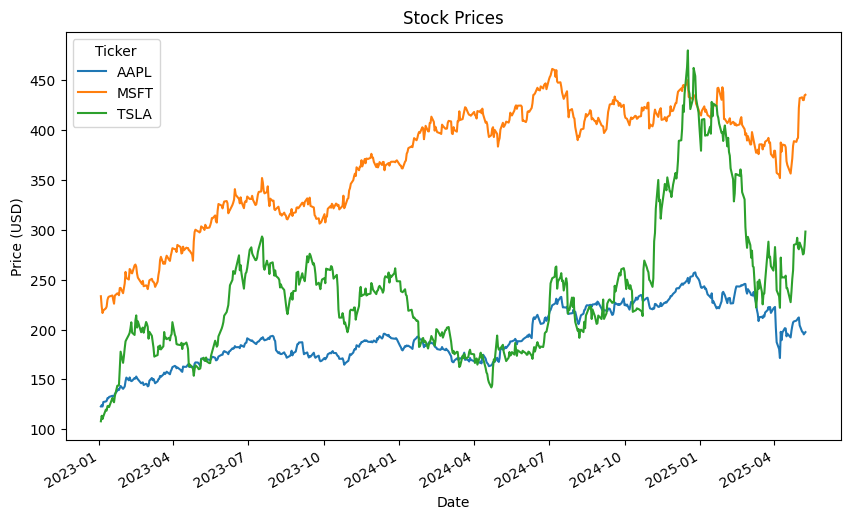

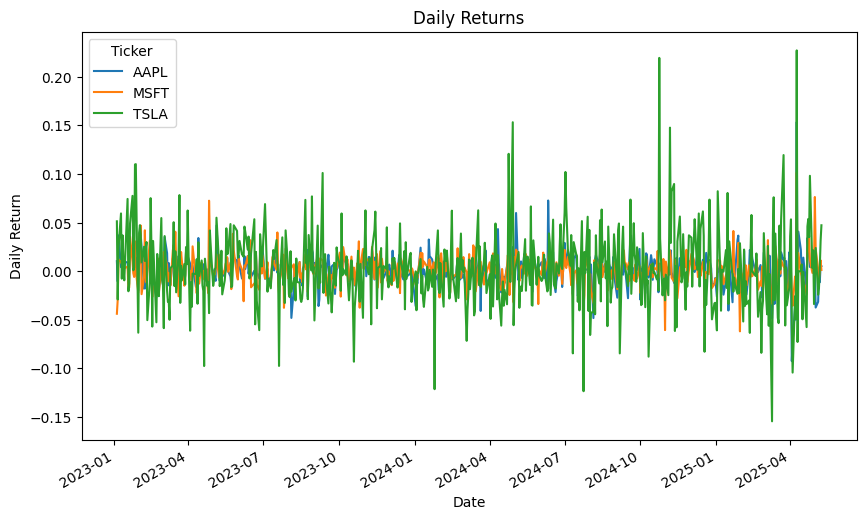

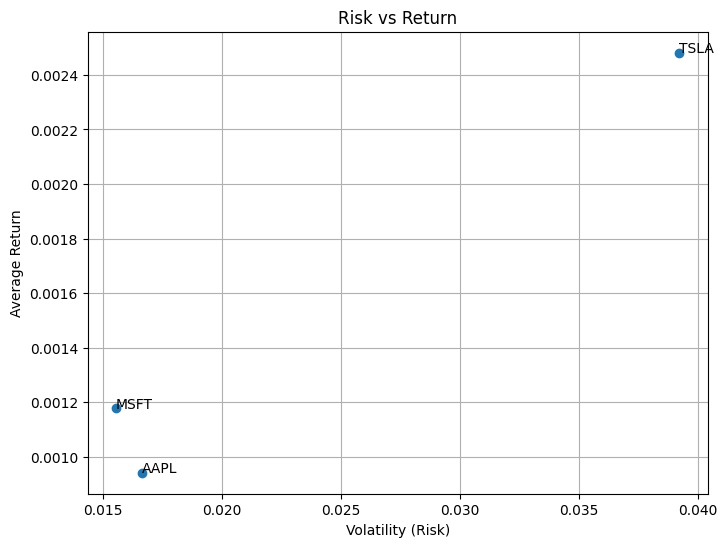

In [4]:

# Plot stock prices
data.plot(figsize=(10, 6), title="Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

# Plot daily returns
returns.plot(figsize=(10, 6), title="Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

# Risk vs Return scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(volatility, avg_returns)

for stock in tickers:
    plt.annotate(stock, (volatility[stock], avg_returns[stock]))

plt.xlabel("Volatility (Risk)")
plt.ylabel("Average Return")
plt.title("Risk vs Return")
plt.grid(True)
plt.show()

Distribution & Probability

In [5]:
threshold = -0.02

for stock in tickers:
    stock_returns = returns[stock].dropna()

    mean = stock_returns.mean()
    std = stock_returns.std()

    if std == 0 or np.isnan(std):
        continue

    prob_below = (stock_returns < threshold).mean() * 100

    print(f"{stock}: {prob_below:.2f}% chance of dropping below {threshold*100:.0f}% in a day")

#___Graphical Stuff___

    # plt.figure(figsize=(10,6))

    # plt.hist(stock_returns, bins=50, density=True, alpha=0.6)

    # x = np.linspace(stock_returns.min(), stock_returns.max(), 100)
    # y = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)

    # plt.plot(x, y, label="Normal Curve")

    # # vertical line showing threshold
    # plt.axvline(threshold, linestyle="--", label=f"{threshold*100:.0f}% Threshold")

    # plt.title(f"{stock} Return Distribution")
    # plt.xlabel("Daily Return")
    # plt.ylabel("Density")
    # plt.legend()
    # plt.grid(True)
    # plt.show()


AAPL: 7.64% chance of dropping below -2% in a day
TSLA: 25.30% chance of dropping below -2% in a day
MSFT: 8.15% chance of dropping below -2% in a day


Correlations

In [6]:
print(returns.corr().round(2))
corr_matrix = returns.corr()

#___Graphical Stuff___

# plt.figure(figsize=(8, 6))
# sns.heatmap(
#     corr_matrix,
#     annot=True,          # show numbers in cells
#     fmt=".2f",           # 2 decimal places
#     cmap="coolwarm",     # red = high correlation, blue = low
#     vmin=-1, vmax=1,     # fix scale
#     square=True,
#     linewidths=0.5
# )

# plt.title("Stock Return Correlation Heatmap")
# plt.tight_layout()
# plt.show()

Ticker  AAPL  MSFT  TSLA
Ticker                  
AAPL    1.00  0.54  0.46
MSFT    0.54  1.00  0.39
TSLA    0.46  0.39  1.00


Sharpe Ratio

In [7]:
risk_free_rate = 0.05 / 252  # daily risk-free rate (Canadian saving interest), 252 trading days

sharpe_ratios = (avg_returns - risk_free_rate) / volatility

print("Sharpe Ratios:")
print(sharpe_ratios.round(2))

# Portfolio Sharpe (equal weights) ***add different weightings later***
weights = np.array([1/len(tickers)] * len(tickers))

portfolio_return = np.dot(weights, avg_returns)
portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(returns.cov(), weights)))
portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility

print(f"\nPortfolio Sharpe Ratio: {portfolio_sharpe:.2f}")

#___Graphical Stuff___

# plt.figure(figsize=(8, 5))
# plt.scatter(sharpe_ratios.values, sharpe_ratios.index, s=100, zorder=3)#individual stock points
# plt.scatter(portfolio_sharpe, "Portfolio", s=150, color="red", zorder=4, marker="*")#portfolio point
# plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
# plt.title("Sharpe Ratio by Stock")
# plt.xlabel("Sharpe Ratio")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


Sharpe Ratios:
Ticker
AAPL    0.04
MSFT    0.06
TSLA    0.06
dtype: float64

Portfolio Sharpe Ratio: 0.07


VaR

In [ ]:
confidence_level = 0.95  # 95% confidence
alpha = 1 - confidence_level

# Historical VaR
historical_var = returns.quantile(alpha)

# Parametric VaR

# replace norm.ppf(confidence_level) with this
z_score = 1.645  # 95% confidence z-score hardcoded

parametric_var = avg_returns - z_score * volatility

# portfolio parametric var
portfolio_param_var = portfolio_return - z_score * portfolio_volatility

# Expected Shortfall (CVaR)
cvar = {}
for stock in tickers:
    below_var = returns[stock][returns[stock] <= historical_var[stock]]
    cvar[stock] = below_var.mean()
cvar = pd.Series(cvar)

# Portfolio VaR
portfolio_returns = returns.dot(weights)
portfolio_hist_var = portfolio_returns.quantile(alpha)
portfolio_cvar = portfolio_returns[portfolio_returns <= portfolio_hist_var].mean()

# Comparison Table
var_table = pd.DataFrame({
    "Historical VaR (95%)": historical_var,
    "Parametric VaR (95%)": parametric_var,
    "Expected Shortfall":   cvar
}).round(4)

# add portfolio row
var_table.loc["Portfolio"] = [portfolio_hist_var, portfolio_param_var, portfolio_cvar]

print("Value at Risk Analysis (95% Confidence):")
print(var_table)

Value at Risk Analysis (95% Confidence):
           Historical VaR (95%)  Parametric VaR (95%)  Expected Shortfall
AAPL                  -0.025900              -0.02640           -0.037700
MSFT                  -0.023600              -0.02440           -0.032300
TSLA                  -0.055200              -0.06210           -0.076800
Portfolio             -0.029942              -0.03051           -0.040107
